In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings
import logging
from transformers import logging as hf_logging

warnings.filterwarnings("ignore")

hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bert_score").setLevel(logging.ERROR)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [6]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [7]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [8]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Температура 0.0

In [9]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_0.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6835, 'grad_norm': 8.686935424804688, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3503, 'grad_norm': 16.51881980895996, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.2252, 'grad_norm': 11.117321968078613, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0694, 'grad_norm': 14.872090339660645, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1332, 'grad_norm': 10.318177223205566, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.039, 'grad_norm': 7.377345561981201, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0605, 'grad_norm': 13.449226379394531, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9770599603652954, 'eval_runtime': 6.8644, 'eval_sam

In [10]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6594
F1 Micro: 0.6594
F1 Macro: 0.6090
F1 Weighted: 0.6538
MAE: 0.4157
              precision    recall  f1-score   support

           1       0.80      0.84      0.82       153
           2       0.59      0.73      0.66       227
           3       0.64      0.72      0.68       475
           4       0.67      0.57      0.61       343
           5       0.67      0.55      0.60       237
           6       1.00      0.17      0.29        30

    accuracy                           0.66      1465
   macro avg       0.73      0.60      0.61      1465
weighted avg       0.67      0.66      0.65      1465



0.6594
0.6594
0.6090
0.6538
0.4157
321.88


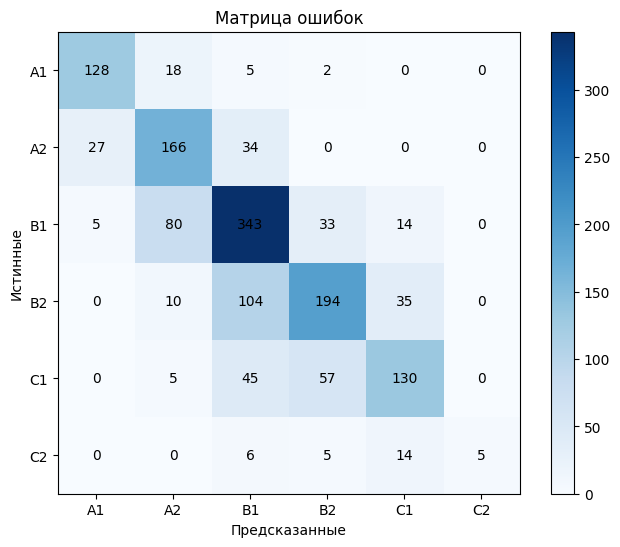

In [11]:
visualize_cm(true_labels, predictions)

# Температура 0.1

In [12]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_1.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6285, 'grad_norm': 7.974370956420898, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3529, 'grad_norm': 9.309663772583008, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1949, 'grad_norm': 12.469735145568848, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0458, 'grad_norm': 12.360001564025879, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1357, 'grad_norm': 14.051591873168945, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0388, 'grad_norm': 9.443660736083984, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0574, 'grad_norm': 8.864169120788574, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9685337543487549, 'eval_runtime': 6.8768, 'eval_sam

In [13]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6130
F1 Micro: 0.6130
F1 Macro: 0.5142
F1 Weighted: 0.6040
MAE: 0.4621
              precision    recall  f1-score   support

           1       0.90      0.41      0.56       153
           2       0.52      0.75      0.61       227
           3       0.61      0.72      0.66       475
           4       0.64      0.55      0.59       343
           5       0.65      0.56      0.60       237
           6       1.00      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.72      0.50      0.51      1465
weighted avg       0.65      0.61      0.60      1465



0.6130
0.6130
0.5142
0.6040
0.4621
327.69


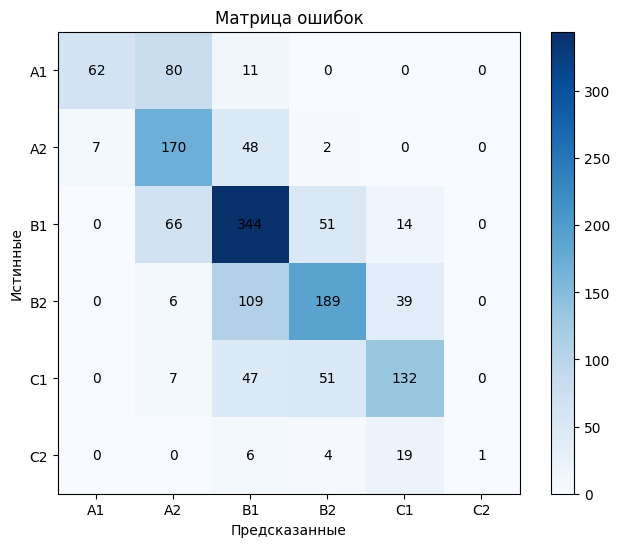

In [14]:
visualize_cm(true_labels, predictions)

# Температура 0.2

In [15]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_3.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6273, 'grad_norm': 9.227489471435547, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.354, 'grad_norm': 10.456339836120605, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1942, 'grad_norm': 13.989314079284668, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0512, 'grad_norm': 12.064410209655762, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1504, 'grad_norm': 12.297805786132812, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.04, 'grad_norm': 8.889512062072754, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0481, 'grad_norm': 8.669233322143555, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9521254301071167, 'eval_runtime': 6.8767, 'eval_sampl

In [16]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6184
F1 Micro: 0.6184
F1 Macro: 0.5286
F1 Weighted: 0.6127
MAE: 0.4505
              precision    recall  f1-score   support

           1       0.90      0.48      0.63       153
           2       0.53      0.74      0.62       227
           3       0.63      0.68      0.65       475
           4       0.61      0.58      0.59       343
           5       0.64      0.59      0.61       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.61      1465



0.6184
0.6184
0.5286
0.6127
0.4505
327.61


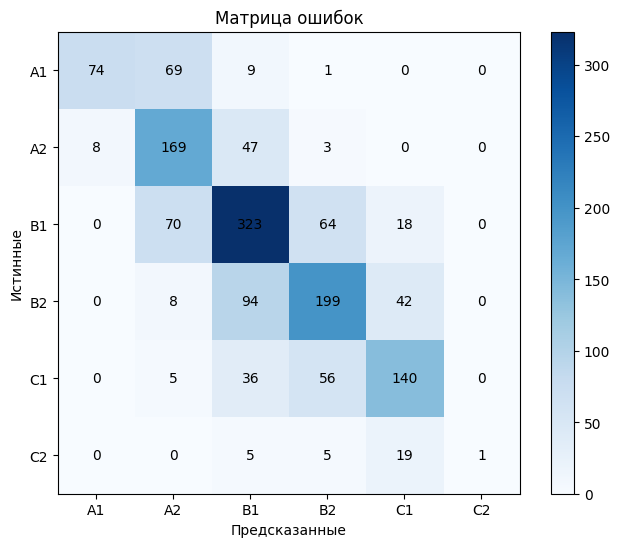

In [17]:
visualize_cm(true_labels, predictions)

# Температура 0.4

In [18]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_4.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6288, 'grad_norm': 7.120154857635498, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3514, 'grad_norm': 10.66379451751709, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1824, 'grad_norm': 10.387884140014648, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0508, 'grad_norm': 13.140069007873535, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1306, 'grad_norm': 13.493006706237793, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0328, 'grad_norm': 9.210436820983887, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0562, 'grad_norm': 9.22049331665039, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9624215364456177, 'eval_runtime': 6.8489, 'eval_samp

In [19]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6137
F1 Micro: 0.6137
F1 Macro: 0.5162
F1 Weighted: 0.6047
MAE: 0.4601
              precision    recall  f1-score   support

           1       0.91      0.41      0.57       153
           2       0.53      0.76      0.62       227
           3       0.61      0.72      0.66       475
           4       0.63      0.55      0.58       343
           5       0.63      0.57      0.60       237
           6       1.00      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.72      0.51      0.52      1465
weighted avg       0.64      0.61      0.60      1465



0.6137
0.6137
0.5162
0.6047
0.4601
327.51


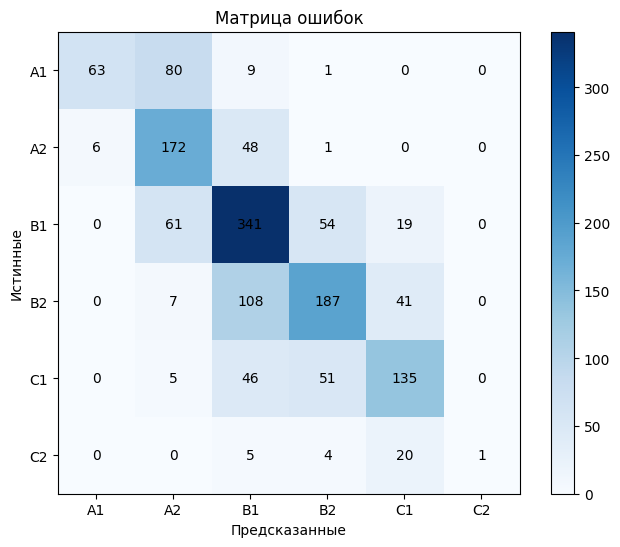

In [20]:
visualize_cm(true_labels, predictions)

# Температура 0.5

In [21]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_5.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6309, 'grad_norm': 6.934408187866211, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3512, 'grad_norm': 9.164957046508789, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1927, 'grad_norm': 11.769492149353027, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0487, 'grad_norm': 11.444608688354492, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.131, 'grad_norm': 13.130599975585938, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0389, 'grad_norm': 8.456399917602539, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0489, 'grad_norm': 9.38141918182373, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9500280618667603, 'eval_runtime': 6.857, 'eval_sample

In [22]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6232
F1 Micro: 0.6232
F1 Macro: 0.5346
F1 Weighted: 0.6180
MAE: 0.4471
              precision    recall  f1-score   support

           1       0.91      0.52      0.66       153
           2       0.54      0.74      0.63       227
           3       0.63      0.68      0.65       475
           4       0.62      0.59      0.60       343
           5       0.61      0.59      0.60       237
           6       0.50      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.64      0.52      0.53      1465
weighted avg       0.64      0.62      0.62      1465



0.6232
0.6232
0.5346
0.6180
0.4471
327.67


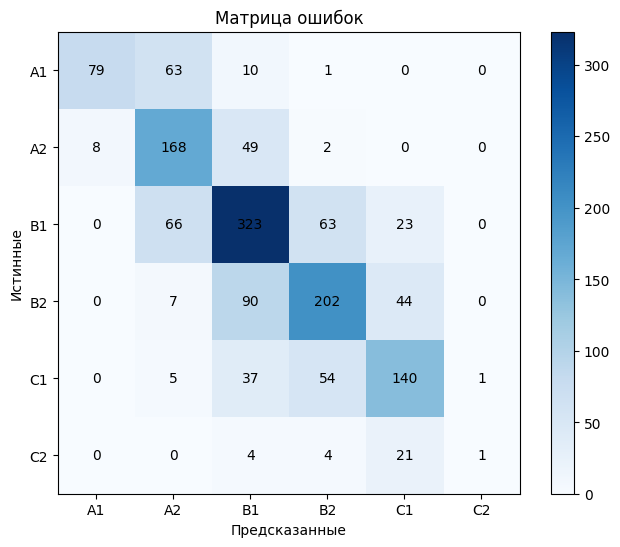

In [23]:
visualize_cm(true_labels, predictions)

# Температура 0.6

In [24]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_6.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6284, 'grad_norm': 7.597467422485352, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3481, 'grad_norm': 10.170619010925293, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1847, 'grad_norm': 9.840723037719727, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0436, 'grad_norm': 12.253901481628418, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1282, 'grad_norm': 13.77096176147461, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.035, 'grad_norm': 8.79747200012207, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0411, 'grad_norm': 9.075166702270508, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9588639140129089, 'eval_runtime': 6.8543, 'eval_sample

In [25]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6143
F1 Micro: 0.6143
F1 Macro: 0.5158
F1 Weighted: 0.6066
MAE: 0.4587
              precision    recall  f1-score   support

           1       0.90      0.41      0.57       153
           2       0.52      0.74      0.61       227
           3       0.63      0.71      0.67       475
           4       0.62      0.58      0.60       343
           5       0.63      0.57      0.60       237
           6       0.50      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.63      0.51      0.52      1465
weighted avg       0.63      0.61      0.61      1465



0.6143
0.6143
0.5158
0.6066
0.4587
328.00


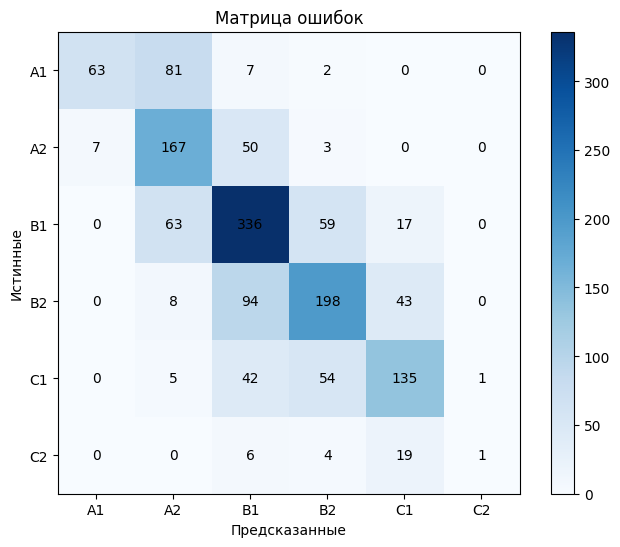

In [26]:
visualize_cm(true_labels, predictions)

# Температура 0.7

In [27]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_7.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6281, 'grad_norm': 6.842495918273926, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3512, 'grad_norm': 9.22659969329834, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1817, 'grad_norm': 10.813720703125, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0564, 'grad_norm': 13.417681694030762, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1182, 'grad_norm': 12.703461647033691, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0358, 'grad_norm': 8.756169319152832, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0467, 'grad_norm': 9.463784217834473, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.950524091720581, 'eval_runtime': 6.8575, 'eval_samples_

In [28]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6171
F1 Micro: 0.6171
F1 Macro: 0.5244
F1 Weighted: 0.6102
MAE: 0.4539
              precision    recall  f1-score   support

           1       0.90      0.47      0.62       153
           2       0.53      0.73      0.62       227
           3       0.62      0.71      0.66       475
           4       0.62      0.57      0.59       343
           5       0.64      0.56      0.60       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.51      0.52      1465
weighted avg       0.64      0.62      0.61      1465



0.6171
0.6171
0.5244
0.6102
0.4539
327.92


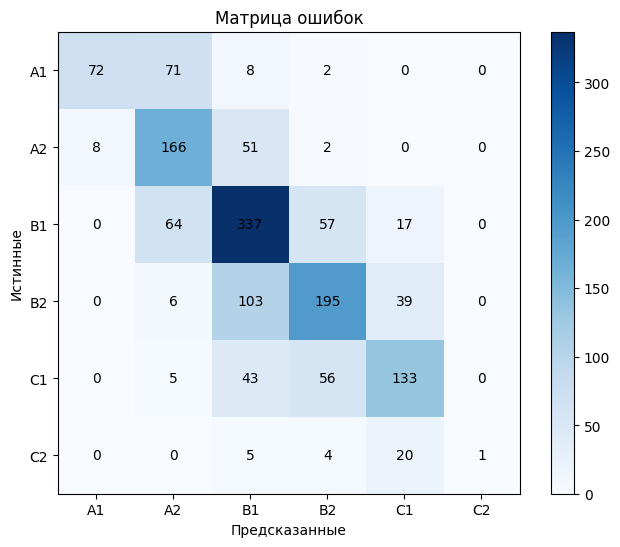

In [29]:
visualize_cm(true_labels, predictions)

# Температура 0.8

In [30]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_8.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6289, 'grad_norm': 6.692265510559082, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3379, 'grad_norm': 9.437435150146484, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1961, 'grad_norm': 10.805691719055176, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0495, 'grad_norm': 11.222331047058105, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1231, 'grad_norm': 13.355239868164062, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0317, 'grad_norm': 8.094780921936035, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0491, 'grad_norm': 9.349737167358398, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9613771438598633, 'eval_runtime': 6.8745, 'eval_sam

In [31]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6130
F1 Micro: 0.6130
F1 Macro: 0.5128
F1 Weighted: 0.6049
MAE: 0.4553
              precision    recall  f1-score   support

           1       0.90      0.40      0.55       153
           2       0.51      0.74      0.60       227
           3       0.63      0.71      0.67       475
           4       0.63      0.57      0.60       343
           5       0.62      0.57      0.59       237
           6       0.50      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.63      0.50      0.51      1465
weighted avg       0.63      0.61      0.60      1465



0.6130
0.6130
0.5128
0.6049
0.4553
327.64


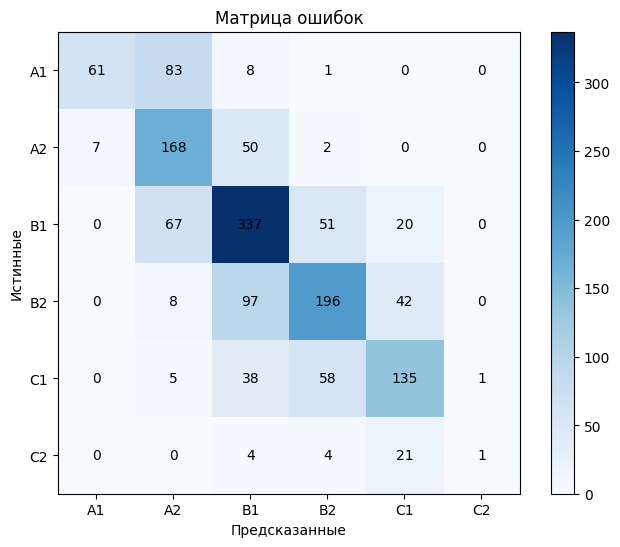

In [32]:
visualize_cm(true_labels, predictions)

# Температура 0.9

In [33]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_0_9.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6255, 'grad_norm': 7.345699787139893, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3439, 'grad_norm': 9.600654602050781, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1804, 'grad_norm': 12.83283805847168, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0503, 'grad_norm': 14.735459327697754, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1261, 'grad_norm': 12.830889701843262, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0429, 'grad_norm': 9.29369831085205, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0466, 'grad_norm': 8.823866844177246, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.961219310760498, 'eval_runtime': 6.8513, 'eval_sample

In [34]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6137
F1 Micro: 0.6137
F1 Macro: 0.5231
F1 Weighted: 0.6070
MAE: 0.4567
              precision    recall  f1-score   support

           1       0.92      0.46      0.62       153
           2       0.53      0.74      0.62       227
           3       0.61      0.70      0.65       475
           4       0.61      0.56      0.59       343
           5       0.64      0.57      0.60       237
           6       1.00      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.72      0.51      0.52      1465
weighted avg       0.64      0.61      0.61      1465



0.6137
0.6137
0.5231
0.6070
0.4567
327.49


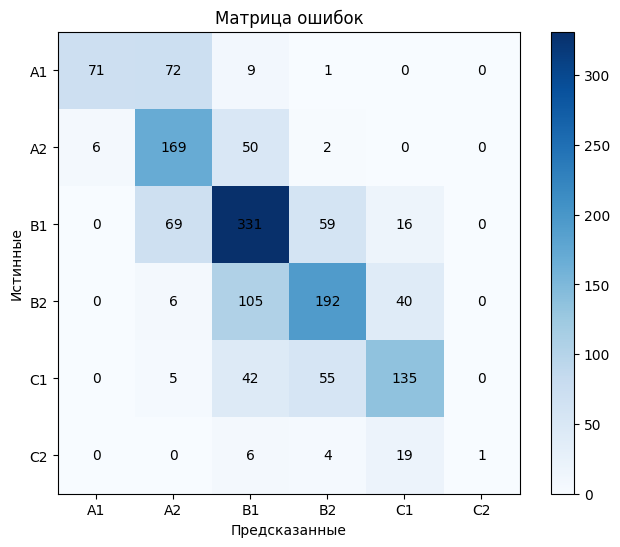

In [35]:
visualize_cm(true_labels, predictions)

# Температура 1.0

In [36]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_1_0.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6295, 'grad_norm': 6.6922712326049805, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3491, 'grad_norm': 9.679874420166016, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1799, 'grad_norm': 11.04544448852539, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0496, 'grad_norm': 16.074052810668945, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1257, 'grad_norm': 13.0903959274292, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.04, 'grad_norm': 8.723156929016113, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0501, 'grad_norm': 8.436545372009277, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9572552442550659, 'eval_runtime': 6.8531, 'eval_samples

In [37]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6130
F1 Micro: 0.6130
F1 Macro: 0.5102
F1 Weighted: 0.6054
MAE: 0.4532
              precision    recall  f1-score   support

           1       0.92      0.45      0.61       153
           2       0.53      0.73      0.61       227
           3       0.62      0.70      0.66       475
           4       0.59      0.58      0.59       343
           5       0.64      0.57      0.60       237
           6       0.00      0.00      0.00        30

    accuracy                           0.61      1465
   macro avg       0.55      0.50      0.51      1465
weighted avg       0.62      0.61      0.61      1465



0.6130
0.6130
0.5102
0.6054
0.4532
327.66


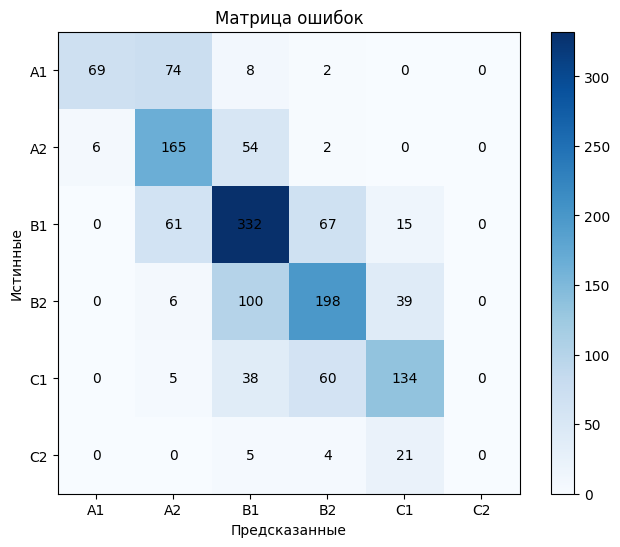

In [38]:
visualize_cm(true_labels, predictions)

# Температура 1.1

In [39]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_1_1.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6312, 'grad_norm': 6.936343669891357, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3583, 'grad_norm': 10.468912124633789, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1792, 'grad_norm': 11.297730445861816, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0421, 'grad_norm': 12.909709930419922, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1317, 'grad_norm': 14.084942817687988, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.04, 'grad_norm': 8.881229400634766, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0447, 'grad_norm': 8.902032852172852, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9477434158325195, 'eval_runtime': 6.8691, 'eval_samp

In [40]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6205
F1 Micro: 0.6205
F1 Macro: 0.5263
F1 Weighted: 0.6138
MAE: 0.4478
              precision    recall  f1-score   support

           1       0.91      0.44      0.60       153
           2       0.53      0.74      0.62       227
           3       0.63      0.68      0.65       475
           4       0.62      0.60      0.61       343
           5       0.63      0.59      0.61       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.61      1465



0.6205
0.6205
0.5263
0.6138
0.4478
327.61


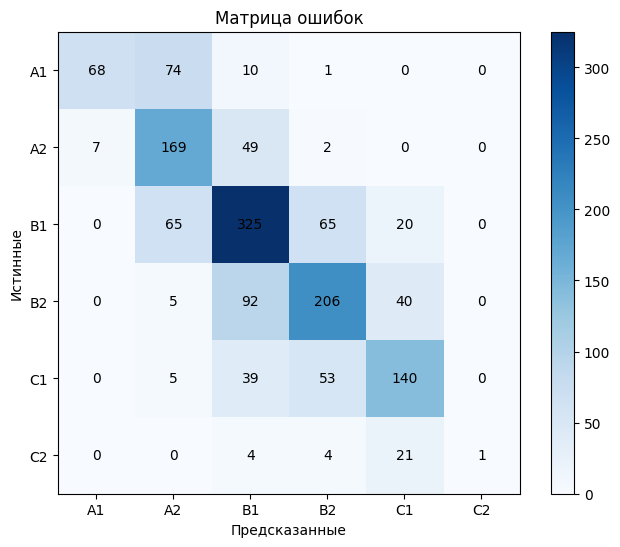

In [41]:
visualize_cm(true_labels, predictions)

# Температура 1.2

In [42]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_1_2.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6302, 'grad_norm': 6.771050453186035, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3576, 'grad_norm': 10.269067764282227, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1922, 'grad_norm': 10.486760139465332, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0589, 'grad_norm': 13.882458686828613, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1283, 'grad_norm': 12.32802677154541, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0333, 'grad_norm': 8.23383617401123, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0577, 'grad_norm': 8.465287208557129, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9557868242263794, 'eval_runtime': 6.8589, 'eval_samp

In [43]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6177
F1 Micro: 0.6177
F1 Macro: 0.5229
F1 Weighted: 0.6106
MAE: 0.4532
              precision    recall  f1-score   support

           1       0.91      0.45      0.60       153
           2       0.54      0.73      0.62       227
           3       0.62      0.71      0.66       475
           4       0.62      0.57      0.59       343
           5       0.64      0.57      0.60       237
           6       0.33      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.61      0.51      0.52      1465
weighted avg       0.63      0.62      0.61      1465



0.6177
0.6177
0.5229
0.6106
0.4532
328.61


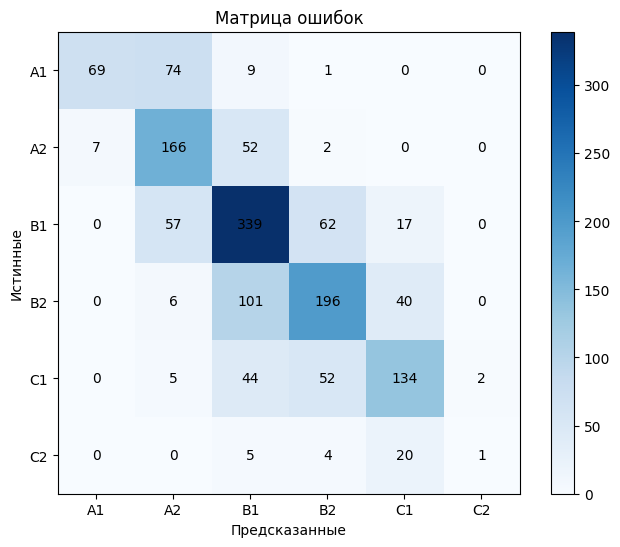

In [44]:
visualize_cm(true_labels, predictions)

# Температура 1.3

In [45]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_1_3.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6298, 'grad_norm': 6.734669208526611, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3418, 'grad_norm': 9.13857364654541, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.185, 'grad_norm': 12.560502052307129, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0472, 'grad_norm': 12.616884231567383, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1273, 'grad_norm': 12.653435707092285, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0253, 'grad_norm': 8.60566234588623, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0408, 'grad_norm': 9.255962371826172, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9529365301132202, 'eval_runtime': 6.8737, 'eval_sample

In [46]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6212
F1 Micro: 0.6212
F1 Macro: 0.5281
F1 Weighted: 0.6146
MAE: 0.4464
              precision    recall  f1-score   support

           1       0.90      0.48      0.62       153
           2       0.53      0.75      0.62       227
           3       0.63      0.70      0.66       475
           4       0.60      0.59      0.60       343
           5       0.65      0.55      0.60       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.61      1465



0.6212
0.6212
0.5281
0.6146
0.4464
327.91


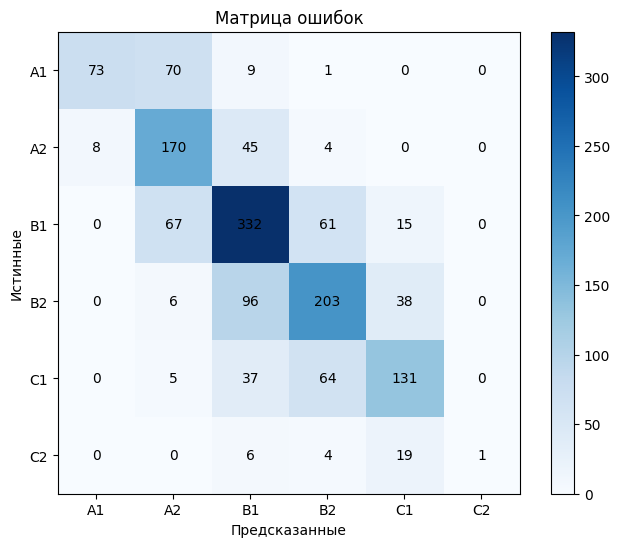

In [47]:
visualize_cm(true_labels, predictions)

# Температура 1.4

In [48]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_1_4.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6279, 'grad_norm': 6.980968952178955, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.341, 'grad_norm': 9.968327522277832, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.1854, 'grad_norm': 14.441953659057617, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0599, 'grad_norm': 15.000503540039062, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1265, 'grad_norm': 13.651399612426758, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0303, 'grad_norm': 8.945622444152832, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.0376, 'grad_norm': 8.639992713928223, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9432067275047302, 'eval_runtime': 6.8687, 'eval_samp

In [49]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6225
F1 Micro: 0.6225
F1 Macro: 0.5330
F1 Weighted: 0.6168
MAE: 0.4457
              precision    recall  f1-score   support

           1       0.92      0.50      0.64       153
           2       0.55      0.74      0.63       227
           3       0.63      0.69      0.66       475
           4       0.60      0.60      0.60       343
           5       0.64      0.58      0.61       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.62      1465



0.6225
0.6225
0.5330
0.6168
0.4457
328.20


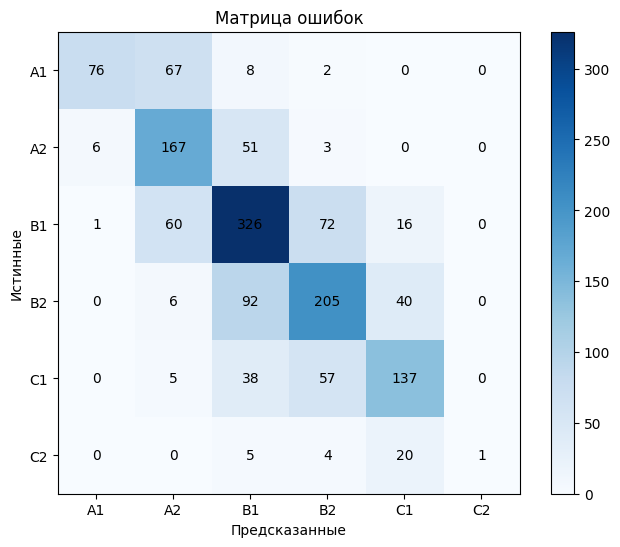

In [50]:
visualize_cm(true_labels, predictions)

# Температура 1.5

In [51]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3_temp_1_5.csv')
model, val_dataset, train_time = fit(c2)

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465
{'loss': 1.6303, 'grad_norm': 7.170793056488037, 'learning_rate': 1.98e-05, 'epoch': 0.13368983957219252}
{'loss': 1.3489, 'grad_norm': 9.738905906677246, 'learning_rate': 1.9076492537313433e-05, 'epoch': 0.26737967914438504}
{'loss': 1.189, 'grad_norm': 11.187817573547363, 'learning_rate': 1.8143656716417912e-05, 'epoch': 0.40106951871657753}
{'loss': 1.0479, 'grad_norm': 13.766587257385254, 'learning_rate': 1.7210820895522388e-05, 'epoch': 0.5347593582887701}
{'loss': 1.1266, 'grad_norm': 12.738658905029297, 'learning_rate': 1.6277985074626867e-05, 'epoch': 0.6684491978609626}
{'loss': 1.0289, 'grad_norm': 8.522222518920898, 'learning_rate': 1.5345149253731342e-05, 'epoch': 0.8021390374331551}
{'loss': 1.046, 'grad_norm': 8.702841758728027, 'learning_rate': 1.4412313432835823e-05, 'epoch': 0.9358288770053476}
{'eval_loss': 0.9509888887405396, 'eval_runtime': 6.8814, 'eval_sampl

In [52]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6198
F1 Micro: 0.6198
F1 Macro: 0.5270
F1 Weighted: 0.6136
MAE: 0.4485
              precision    recall  f1-score   support

           1       0.91      0.45      0.60       153
           2       0.53      0.75      0.62       227
           3       0.64      0.67      0.65       475
           4       0.61      0.61      0.61       343
           5       0.64      0.59      0.61       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.61      1465



0.6198
0.6198
0.5270
0.6136
0.4485
328.14


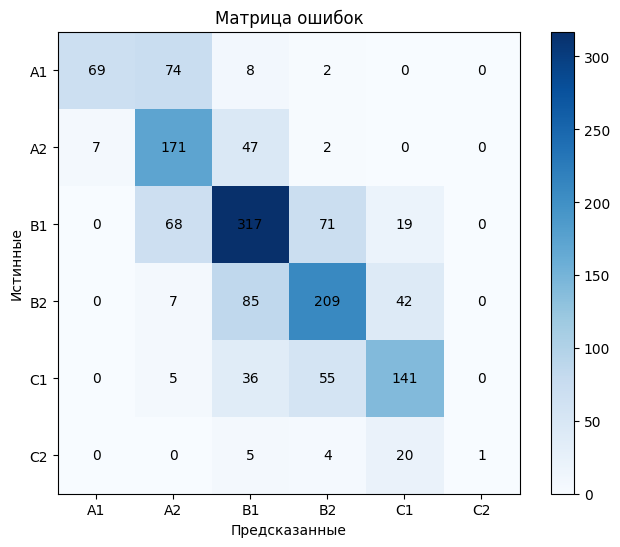

In [53]:
visualize_cm(true_labels, predictions)